# 第五课：神经网络基础 —— 全连接网络与激活函数

## 为什么需要神经网络？

线性回归和逻辑回归都是**线性模型**，只能解决线性可分的问题。

现实中的问题大多是**非线性**的，神经网络通过叠加多层线性变换 + 非线性激活函数，
可以逼近任意复杂的函数（万能逼近定理）。

## 本课内容

1. 激活函数详解
2. 多层感知器（MLP）结构
3. 非线性分类实战
4. 前向传播与反向传播
5. 隐藏层维度的影响
6. 权重初始化

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

## 1. 激活函数详解

如果没有激活函数，多层线性变换等价于一层线性变换：

$$W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2)$$

激活函数引入非线性，使网络有能力学习复杂模式。

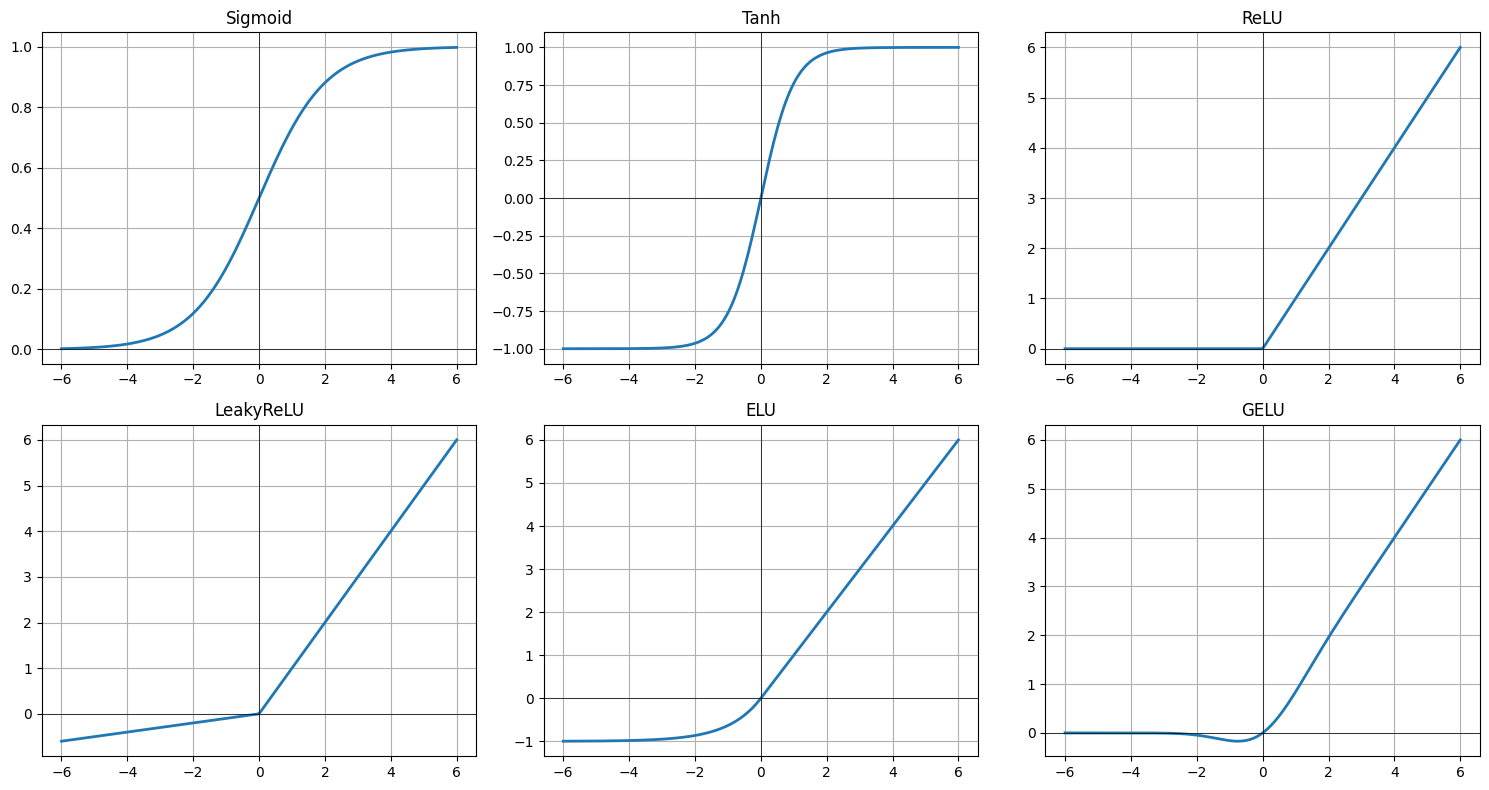

In [2]:
# 常见激活函数可视化
z = torch.linspace(-6, 6, 200)

activations = {
    'Sigmoid': torch.sigmoid(z),
    'Tanh': torch.tanh(z),
    'ReLU': torch.relu(z),
    'LeakyReLU': nn.LeakyReLU(0.1)(z),
    'ELU': nn.ELU()(z),
    'GELU': nn.GELU()(z),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, vals) in zip(axes.flatten(), activations.items()):
    ax.plot(z.numpy(), vals.numpy(), linewidth=2)
    ax.set_title(name)
    ax.grid(True)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

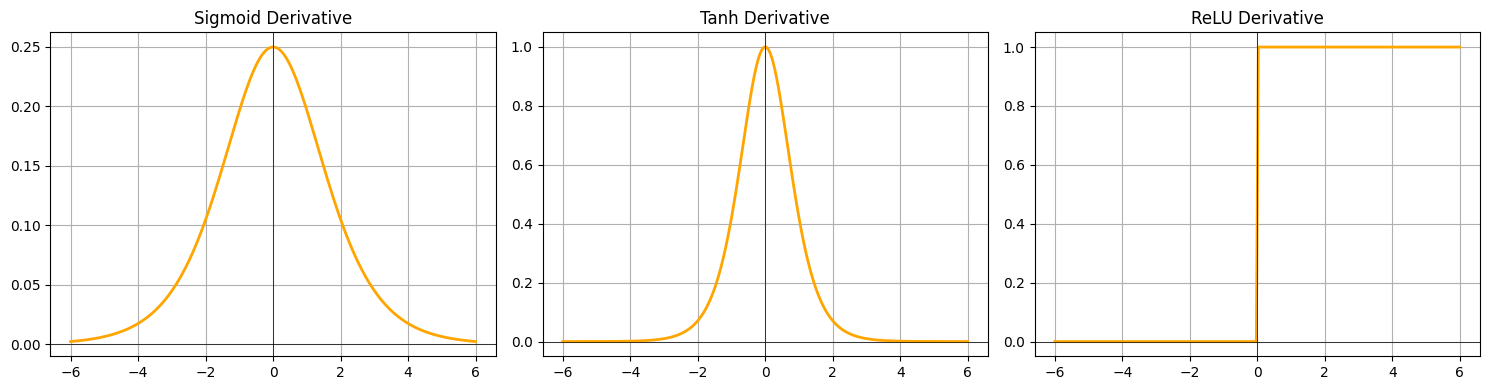

激活函数对比：
  Sigmoid: 输出(0,1)，导数最大0.25 → 容易梯度消失
  Tanh:    输出(-1,1)，导数最大1.0 → 比Sigmoid好，但仍可能梯度消失
  ReLU:    正区间导数恒为1 → 缓解梯度消失，但负区间死掉(Dead ReLU)
  LeakyReLU: 负区间有小梯度 → 解决Dead ReLU
  GELU:    平滑的ReLU变体 → Transformer中常用


In [4]:
# 激活函数的导数
z = torch.linspace(-6, 6, 200)
z.requires_grad_(True)

# 用 Autograd 计算导数
derivs = {}
for name, fn in [('Sigmoid', torch.sigmoid),
                  ('Tanh', torch.tanh),
                  ('ReLU', torch.relu)]:
    z_copy = z.clone().detach().requires_grad_(True)
    y = fn(z_copy)
    y.sum().backward()
    derivs[name] = z_copy.grad.clone()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, d) in zip(axes, derivs.items()):
    ax.plot(z.detach().numpy(), d.numpy(), linewidth=2, color='orange')
    ax.set_title(f"{name} Derivative")
    ax.grid(True)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("激活函数对比：")
print("  Sigmoid: 输出(0,1)，导数最大0.25 → 容易梯度消失")
print("  Tanh:    输出(-1,1)，导数最大1.0 → 比Sigmoid好，但仍可能梯度消失")
print("  ReLU:    正区间导数恒为1 → 缓解梯度消失，但负区间死掉(Dead ReLU)")
print("  LeakyReLU: 负区间有小梯度 → 解决Dead ReLU")
print("  GELU:    平滑的ReLU变体 → Transformer中常用")

## 2. 多层感知器（MLP）结构

```
输入层 → 隐藏层1 → 隐藏层2 → 输出层
  x  →  h1=σ(W1·x+b1) → h2=σ(W2·h1+b2) → y=W3·h2+b3
```

关键：每层之间必须有激活函数！否则多层等价于一层。

In [6]:
# 方式1：用 nn.Sequential 快速定义
model_seq = nn.Sequential(
    nn.Linear(2, 16),    # 输入层 → 隐藏层1
    nn.ReLU(),           # 激活函数
    nn.Linear(16, 16),   # 隐藏层1 → 隐藏层2
    nn.ReLU(),           # 激活函数
    nn.Linear(16, 2)     # 隐藏层2 → 输出层（2分类用2个输出）
)

print("nn.Sequential 模型:")
print(model_seq)
print(f"\n总参数量: {sum(p.numel() for p in model_seq.parameters()):,}")

nn.Sequential 模型:
Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=2, bias=True)
)

总参数量: 354


In [7]:
# 方式2：自定义 Module（更灵活，推荐）
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)  # 最后一层不加激活函数！
        return x

model_mlp = MLP(input_dim=2, hidden_dim=16, output_dim=2)
print("自定义 MLP 模型:")
print(model_mlp)

print("\n各层参数:")
for name, param in model_mlp.named_parameters():
    print(f"  {name}: shape={param.shape}")

自定义 MLP 模型:
MLP(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=16, bias=True)
  (layer3): Linear(in_features=16, out_features=2, bias=True)
  (relu): ReLU()
)

各层参数:
  layer1.weight: shape=torch.Size([16, 2])
  layer1.bias: shape=torch.Size([16])
  layer2.weight: shape=torch.Size([16, 16])
  layer2.bias: shape=torch.Size([16])
  layer3.weight: shape=torch.Size([2, 16])
  layer3.bias: shape=torch.Size([2])


In [8]:
# 方式3：用 nn.ModuleList 动态创建层
class DynamicMLP(nn.Module):
    def __init__(self, layer_sizes):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layer_sizes) - 1):
            self.layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
        self.relu = nn.ReLU()
    
    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:  # 中间层加激活函数
                x = self.relu(x)
        return x

model_dynamic = DynamicMLP([2, 32, 16, 8, 2])
print("动态 MLP 模型:")
print(model_dynamic)
print(f"层数: {len(model_dynamic.layers)}")

动态 MLP 模型:
DynamicMLP(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Linear(in_features=32, out_features=16, bias=True)
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): Linear(in_features=8, out_features=2, bias=True)
  )
  (relu): ReLU()
)
层数: 4


---
## 3. 非线性分类实战：XOR 问题

XOR 是经典的非线性问题，单层感知器无法解决，但 MLP 可以。

X shape: torch.Size([600, 2]), y shape: torch.Size([600])


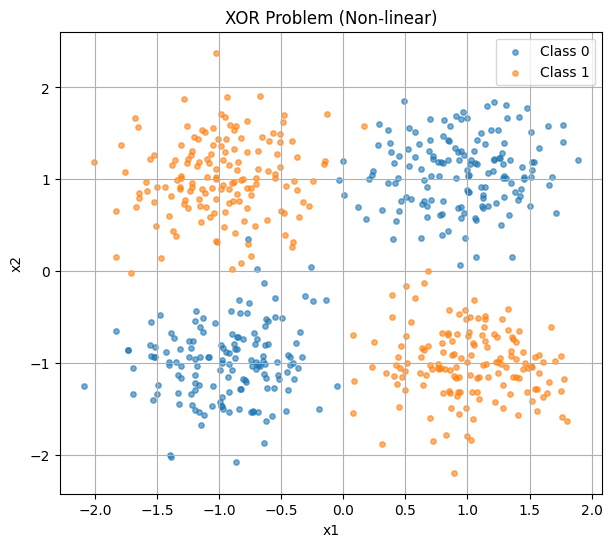

In [9]:
# 生成 XOR 数据
torch.manual_seed(42)
n_per_class = 200

# XOR: (0,0)→0, (1,1)→0, (0,1)→1, (1,0)→1
X_xor = torch.randn(n_per_class * 2, 2) * 0.5
X_xor[:n_per_class] += torch.tensor([1.0, 1.0])   # 类别1：右上
X_xor[:n_per_class] += torch.tensor([-1.0, -1.0]) # 类别1：左下
X_xor[n_per_class:] += torch.tensor([1.0, -1.0])  # 类别0：右下
X_xor[n_per_class:] += torch.tensor([-1.0, 1.0])  # 类别0：左上

# 更清晰的 XOR
torch.manual_seed(42)
n = 150
X0_a = torch.randn(n, 2) * 0.4 + torch.tensor([1.0, 1.0])
X0_b = torch.randn(n, 2) * 0.4 + torch.tensor([-1.0, -1.0])
X1_a = torch.randn(n, 2) * 0.4 + torch.tensor([1.0, -1.0])
X1_b = torch.randn(n, 2) * 0.4 + torch.tensor([-1.0, 1.0])

X_xor = torch.cat([X0_a, X0_b, X1_a, X1_b], dim=0)
y_xor = torch.cat([torch.zeros(2*n), torch.ones(2*n)]).long()

idx = torch.randperm(len(y_xor))
X_xor = X_xor[idx]
y_xor = y_xor[idx]

print(f"X shape: {X_xor.shape}, y shape: {y_xor.shape}")

plt.figure(figsize=(7, 6))
plt.scatter(X_xor[y_xor==0, 0].numpy(), X_xor[y_xor==0, 1].numpy(), s=15, alpha=0.6, label='Class 0')
plt.scatter(X_xor[y_xor==1, 0].numpy(), X_xor[y_xor==1, 1].numpy(), s=15, alpha=0.6, label='Class 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('XOR Problem (Non-linear)')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# 对比：线性模型 vs MLP

# 线性模型（逻辑回归）
linear_model = nn.Linear(2, 2)

# MLP
mlp_model = MLP(input_dim=2, hidden_dim=32, output_dim=2)

criterion = nn.CrossEntropyLoss()

def train_model(model, X, y, epochs=300, lr=0.1):
    optimizer = optim.SGD(model.parameters(), lr=lr)
    losses = []
    accuracies = []
    
    for epoch in range(epochs):
        logits = model(X)
        loss = criterion(logits, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        acc = (logits.argmax(dim=1) == y).float().mean()
        losses.append(loss.item())
        accuracies.append(acc.item())
    
    return losses, accuracies

linear_losses, linear_accs = train_model(linear_model, X_xor, y_xor, epochs=300)
mlp_losses, mlp_accs = train_model(mlp_model, X_xor, y_xor, epochs=300)

print(f"线性模型 - 最终: loss={linear_losses[-1]:.4f}, acc={linear_accs[-1]:.4f}")
print(f"MLP模型  - 最终: loss={mlp_losses[-1]:.4f}, acc={mlp_accs[-1]:.4f}")

线性模型 - 最终: loss=0.6930, acc=0.5000
MLP模型  - 最终: loss=0.0373, acc=0.9917


C:\Users\Administrator\AppData\Local\Temp\ipykernel_22540\3539951762.py:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))


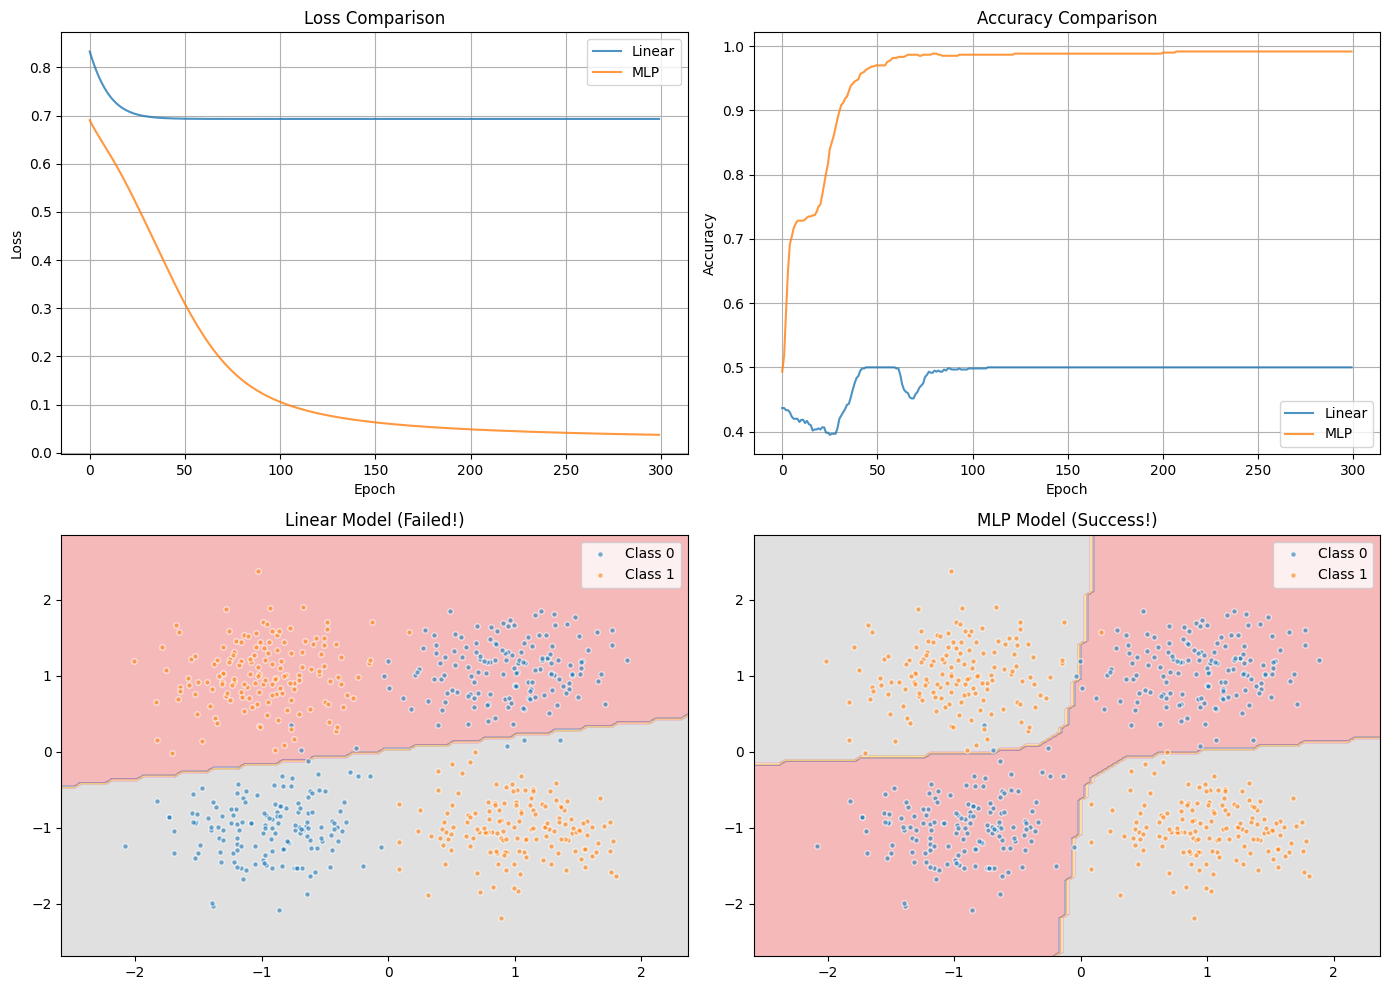

💡 线性模型只能画直线决策边界，无法解决 XOR 问题！
💡 MLP 通过隐藏层 + 激活函数，可以学习非线性决策边界！


In [11]:
# 可视化对比
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 损失对比
axes[0, 0].plot(linear_losses, label='Linear', alpha=0.8)
axes[0, 0].plot(mlp_losses, label='MLP', alpha=0.8)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 准确率对比
axes[0, 1].plot(linear_accs, label='Linear', alpha=0.8)
axes[0, 1].plot(mlp_accs, label='MLP', alpha=0.8)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 决策边界
def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.05
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        pred = model(grid).argmax(dim=1).reshape(xx.shape)
    ax.contourf(xx, yy, pred.numpy(), alpha=0.3, cmap='Set1')
    for c in range(2):
        mask = y == c
        ax.scatter(X[mask, 0].numpy(), X[mask, 1].numpy(), s=15, alpha=0.6, edgecolors='white', label=f'Class {c}')
    ax.set_title(title)
    ax.legend()

plot_boundary(axes[1, 0], linear_model, X_xor, y_xor, 'Linear Model (Failed!)')
plot_boundary(axes[1, 1], mlp_model, X_xor, y_xor, 'MLP Model (Success!)')

plt.tight_layout()
plt.show()

print("💡 线性模型只能画直线决策边界，无法解决 XOR 问题！")
print("💡 MLP 通过隐藏层 + 激活函数，可以学习非线性决策边界！")

---
## 4. 前向传播与反向传播详解

In [13]:
# 手动模拟前向传播，理解每一步
torch.manual_seed(0)

# 一个简单的 2层网络
W1 = torch.randn(2, 4, requires_grad=True)  # 输入2维 → 隐藏4维
b1 = torch.zeros(4, requires_grad=True)
W2 = torch.randn(4, 1, requires_grad=True)  # 隐藏4维 → 输出1维
b2 = torch.zeros(1, requires_grad=True)

x = torch.tensor([[0.5, -0.3]])  # 1个样本
target = torch.tensor([[1.0]])

print("=== 前向传播 ===")
print(f"输入 x: {x}")

# 第1层：线性变换
z1 = x @ W1 + b1
print(f"\n第1层线性: z1 = x @ W1.T + b1")
print(f"  z1 = {z1}")

# 第1层：激活函数
h1 = torch.relu(z1)
print(f"\n第1层激活: h1 = ReLU(z1)")
print(f"  h1 = {h1}")

# 第2层：线性变换
z2 = h1 @ W2 + b2
print(f"\n第2层线性: z2 = h1 @ W2.T + b2")
print(f"  z2 = {z2}")

# 损失
loss = ((z2 - target) ** 2).mean()
print(f"\n损失: L = MSE(z2, target) = {loss.item():.6f}")

=== 前向传播 ===
输入 x: tensor([[ 0.5000, -0.3000]])

第1层线性: z1 = x @ W1.T + b1
  z1 = tensor([[ 1.0959,  0.2729, -1.2104,  0.0328]], grad_fn=<AddBackward0>)

第1层激活: h1 = ReLU(z1)
  h1 = tensor([[1.0959, 0.2729, 0.0000, 0.0328]], grad_fn=<ReluBackward0>)

第2层线性: z2 = h1 @ W2.T + b2
  z2 = tensor([[-0.8923]], grad_fn=<AddBackward0>)

损失: L = MSE(z2, target) = 3.580753


In [14]:
print("=== 反向传播 ===")
loss.backward()

print(f"\ndL/dW2 的形状: {W2.grad.shape}")
print(f"dL/dW2:\n{W2.grad}")
print(f"\ndL/db2 的形状: {b2.grad.shape}")
print(f"dL/db2: {b2.grad}")
print(f"\ndL/dW1 的形状: {W1.grad.shape}")
print(f"dL/dW1:\n{W1.grad}")
print(f"\ndL/db1 的形状: {b1.grad.shape}")
print(f"dL/db1: {b1.grad}")

print("\n💡 反向传播通过链式法则，从输出层向输入层逐层计算梯度")
print("💡 Autograd 自动完成这一切，我们不需要手动推导！")

=== 反向传播 ===

dL/dW2 的形状: torch.Size([4, 1])
dL/dW2:
tensor([[-4.1473],
        [-1.0327],
        [ 0.0000],
        [-0.1242]])

dL/db2 的形状: torch.Size([1])
dL/db2: tensor([-3.7846])

dL/dW1 的形状: torch.Size([2, 4])
dL/dW1:
tensor([[ 1.3610,  0.7632,  0.0000, -0.3445],
        [-0.8166, -0.4579, -0.0000,  0.2067]])

dL/db1 的形状: torch.Size([4])
dL/db1: tensor([ 2.7221,  1.5265,  0.0000, -0.6889])

💡 反向传播通过链式法则，从输出层向输入层逐层计算梯度
💡 Autograd 自动完成这一切，我们不需要手动推导！


## 5. 隐藏层维度的影响

In [ ]:
# 生成螺旋形数据（更复杂的非线性问题）
torch.manual_seed(42)
n = 200

theta = torch.linspace(0, 4 * np.pi, n)
r = torch.linspace(0.5, 2, n)

X_spiral_0 = torch.stack([r * torch.cos(theta), r * torch.sin(theta)], dim=1)
X_spiral_0 += 0.15 * torch.randn(n, 2)

X_spiral_1 = torch.stack([-r * torch.cos(theta), -r * torch.sin(theta)], dim=1)
X_spiral_1 += 0.15 * torch.randn(n, 2)

X_spiral = torch.cat([X_spiral_0, X_spiral_1], dim=0)
y_spiral = torch.cat([torch.zeros(n), torch.ones(n)]).long()

idx = torch.randperm(len(y_spiral))
X_spiral = X_spiral[idx]
y_spiral = y_spiral[idx]

plt.figure(figsize=(7, 6))
plt.scatter(X_spiral[y_spiral==0, 0].numpy(), X_spiral[y_spiral==0, 1].numpy(), s=15, alpha=0.6, label='Class 0')
plt.scatter(X_spiral[y_spiral==1, 0].numpy(), X_spiral[y_spiral==1, 1].numpy(), s=15, alpha=0.6, label='Class 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Spiral Data (Complex Non-linear)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 不同隐藏层维度的对比
hidden_sizes = [4, 16, 64, 128]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, h_size in zip(axes, hidden_sizes):
    torch.manual_seed(42)
    model = MLP(input_dim=2, hidden_dim=h_size, output_dim=2)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(500):
        logits = model(X_spiral)
        loss = criterion(logits, y_spiral)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    final_acc = (model(X_spiral).argmax(dim=1) == y_spiral).float().mean().item()
    n_params = sum(p.numel() for p in model.parameters())
    
    plot_boundary(ax, model, X_spiral, y_spiral, f'Hidden={h_size}, Acc={final_acc:.3f}, Params={n_params}')

plt.tight_layout()
plt.show()

print("💡 隐藏层维度越大，模型容量越大，能学习更复杂的边界")
print("💡 但太大也可能过拟合，需要平衡！")

## 6. 权重初始化

好的初始化可以：
- 避免梯度消失/爆炸
- 加速收敛
- 提高最终性能

In [ ]:
# 常见初始化方法
print("=== 权重初始化方法 ===\n")

def show_init(name, tensor):
    print(f"{name}: mean={tensor.mean().item():.4f}, std={tensor.std().item():.4f}, "
          f"min={tensor.min().item():.4f}, max={tensor.max().item():.4f}")

n_in, n_out = 256, 256

# 默认初始化（Kaiming Uniform）
layer_default = nn.Linear(n_in, n_out)
show_init("默认 (Kaiming Uniform)", layer_default.weight.data)

# Xavier/Glorot 初始化（适合 Sigmoid/Tanh）
layer_xavier = nn.Linear(n_in, n_out)
nn.init.xavier_uniform_(layer_xavier.weight)
show_init("Xavier Uniform", layer_xavier.weight.data)

# Kaiming/He 初始化（适合 ReLU）
layer_kaiming = nn.Linear(n_in, n_out)
nn.init.kaiming_normal_(layer_kaiming.weight, mode='fan_in', nonlinearity='relu')
show_init("Kaiming Normal (ReLU)", layer_kaiming.weight.data)

# 全零初始化（❌ 绝对不要用！）
layer_zero = nn.Linear(n_in, n_out)
nn.init.zeros_(layer_zero.weight)
show_init("全零 (❌ 错误)", layer_zero.weight.data)

print("\n⚠️ 全零初始化的问题：所有神经元输出相同，梯度也相同，无法学习不同特征")
print("✅ ReLU 激活 → 用 Kaiming 初始化")
print("✅ Sigmoid/Tanh 激活 → 用 Xavier 初始化")

In [ ]:
# 初始化对训练的影响
torch.manual_seed(42)

init_methods = {
    'Kaiming (Recommended)': lambda m: nn.init.kaiming_normal_(m.weight, nonlinearity='relu') if hasattr(m, 'weight') else None,
    'Xavier': lambda m: nn.init.xavier_uniform_(m.weight) if hasattr(m, 'weight') else None,
    'Normal(0,1)': lambda m: nn.init.normal_(m.weight, 0, 1) if hasattr(m, 'weight') else None,
    'Normal(0,0.01)': lambda m: nn.init.normal_(m.weight, 0, 0.01) if hasattr(m, 'weight') else None,
}

init_results = {}

for name, init_fn in init_methods.items():
    torch.manual_seed(42)
    model = MLP(input_dim=2, hidden_dim=64, output_dim=2)
    model.apply(init_fn)
    
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    
    losses = []
    for epoch in range(300):
        logits = model(X_spiral)
        loss = criterion(logits, y_spiral)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    init_results[name] = losses
    print(f"{name}: 最终 loss={losses[-1]:.4f}")

plt.figure(figsize=(8, 5))
for name, losses in init_results.items():
    plt.plot(losses, label=name, alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Effect of Weight Initialization')
plt.legend()
plt.grid(True)
plt.show()

## 7. 实战：MNIST 手写数字分类（简化版）

用 MLP 对 MNIST 手写数字进行分类，这是深度学习的 "Hello World"。

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# 生成简化的数字数据（模拟 MNIST 的 28x28=784 维输入）
# 如果有 torchvision，可以直接加载真实 MNIST
try:
    from torchvision import datasets, transforms
    has_torchvision = True
    print("检测到 torchvision，将使用真实 MNIST 数据")
except ImportError:
    has_torchvision = False
    print("未检测到 torchvision，将使用模拟数据")

In [ ]:
if has_torchvision:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)
    
    print(f"训练集大小: {len(train_dataset)}")
    print(f"测试集大小: {len(test_dataset)}")
    print(f"图片形状: {train_dataset[0][0].shape}")  # (1, 28, 28)
    
    # 显示一些样本
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, ax in enumerate(axes.flatten()):
        img, label = train_dataset[i]
        ax.imshow(img.squeeze().numpy(), cmap='gray')
        ax.set_title(f'Label: {label}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("请安装 torchvision: pip install torchvision")

In [ ]:
if has_torchvision:
    # 定义 MNIST 分类器
    class MNISTClassifier(nn.Module):
        def __init__(self):
            super().__init__()
            self.flatten = nn.Flatten()          # (1, 28, 28) → (784,)
            self.network = nn.Sequential(
                nn.Linear(784, 256),
                nn.ReLU(),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Linear(128, 10)               # 10个数字类别
            )
        
        def forward(self, x):
            x = self.flatten(x)
            return self.network(x)
    
    model_mnist = MNISTClassifier()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_mnist.parameters(), lr=0.001)
    
    print(model_mnist)
    print(f"\n总参数量: {sum(p.numel() for p in model_mnist.parameters()):,}")

In [ ]:
if has_torchvision:
    # 训练
    train_losses = []
    train_accs = []
    
    for epoch in range(10):
        model_mnist.train()
        epoch_loss = 0
        correct = 0
        total = 0
        
        for X_batch, y_batch in train_loader:
            logits = model_mnist(X_batch)
            loss = criterion(logits, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * X_batch.size(0)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total += X_batch.size(0)
        
        avg_loss = epoch_loss / total
        acc = correct / total
        train_losses.append(avg_loss)
        train_accs.append(acc)
        print(f"Epoch {epoch+1:2d}: loss={avg_loss:.4f}, accuracy={acc:.4f}")
    
    print(f"\n最终训练准确率: {train_accs[-1]:.4f}")

In [ ]:
if has_torchvision:
    # 测试集评估
    model_mnist.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model_mnist(X_batch)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total += X_batch.size(0)
    
    test_acc = correct / total
    print(f"测试集准确率: {test_acc:.4f}")
    
    # 可视化训练过程
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(train_losses)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].grid(True)
    
    axes[1].plot(train_accs)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training Accuracy')
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

In [ ]:
if has_torchvision:
    # 可视化预测结果
    model_mnist.eval()
    images, labels = next(iter(test_loader))
    
    with torch.no_grad():
        logits = model_mnist(images)
        preds = logits.argmax(dim=1)
    
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(images[i].squeeze().numpy(), cmap='gray')
        color = 'green' if preds[i] == labels[i] else 'red'
        ax.set_title(f'Pred: {preds[i]} (True: {labels[i]})', color=color)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

---
## 📝 第五课总结

### 激活函数选择指南

| 激活函数 | 优点 | 缺点 | 推荐场景 |
|----------|------|------|----------|
| ReLU | 简单、快速、缓解梯度消失 | Dead ReLU | 隐藏层默认选择 |
| LeakyReLU | 解决 Dead ReLU | 需要调超参 | ReLU 效果不好时 |
| GELU | 平滑、性能好 | 计算稍慢 | Transformer |
| Sigmoid | 输出(0,1) | 梯度消失 | 二分类输出层 |
| Tanh | 输出(-1,1) | 梯度消失 | RNN 隐藏层 |

### MLP 设计要点

1. **每层之间加激活函数**（否则多层等价于一层）
2. **最后一层不加激活函数**（由损失函数决定）
3. **隐藏层维度**：从小开始，逐步增大
4. **权重初始化**：ReLU 用 Kaiming，Sigmoid/Tanh 用 Xavier
5. **不要全零初始化**

### PyTorch 定义模型的三种方式

```python
# 1. nn.Sequential（简单快速）
model = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 2))

# 2. 自定义 Module（推荐，最灵活）
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 16)
    def forward(self, x):
        return self.layer1(x)

# 3. nn.ModuleList（动态层数）
self.layers = nn.ModuleList([nn.Linear(n, m) for n, m in sizes])
```